## Step 1: System Setup — Ti₂O₄ Anatase Cluster

In [2]:
import numpy as np
from pyscf import gto, scf, dft, mcscf, ao2mo
from pyscf.tools import molden
import warnings
warnings.filterwarnings('ignore')

# Ti2O4 anatase-derived cluster geometry (Angstroms)
mol = gto.Mole()
mol.atom = """
    Ti   0.000   0.000   0.000
    Ti   1.892   1.892   0.950
    O    0.946   0.946   0.000
    O   -0.946  -0.946   0.000
    O    0.946   2.838   0.950
    O    2.838   0.946   0.950
"""
mol.basis = 'def2-svp'
mol.charge = 0
mol.spin = 0
mol.symmetry = False
mol.verbose = 1
mol.max_memory = 4000
mol.build()

print(f"Formula: Ti2O4")
print(f"Total electrons: {mol.nelectron}")
print(f"Atomic orbitals: {mol.nao_nr()}")
print(f"Basis: def2-SVP")


Formula: Ti2O4
Total electrons: 76
Atomic orbitals: 118
Basis: def2-SVP


## Step 2: Restricted Hartree-Fock (RHF)

In [3]:
mf_hf = scf.RHF(mol)
mf_hf.max_cycle = 200
mf_hf.conv_tol = 1e-9
ehf = mf_hf.kernel()

mo_energy = mf_hf.mo_energy
mo_occ = mf_hf.mo_occ
homo_idx = np.where(mo_occ > 0)[0][-1]
lumo_idx = homo_idx + 1

print(f"HF Energy: {ehf:.10f} Hartree")
print(f"Converged: {mf_hf.converged}")
print(f"HOMO: {mo_energy[homo_idx]*27.2114:.4f} eV")
print(f"LUMO: {mo_energy[lumo_idx]*27.2114:.4f} eV")
print(f"HOMO-LUMO gap: {(mo_energy[lumo_idx]-mo_energy[homo_idx])*27.2114:.4f} eV")


HF Energy: -1994.6516011597 Hartree
Converged: True
HOMO: -3.8742 eV
LUMO: -0.0259 eV
HOMO-LUMO gap: 3.8484 eV


## Step 3: DFT (B3LYP/def2-SVP)

In [4]:
mf_dft = dft.RKS(mol)
mf_dft.xc = 'b3lyp'
mf_dft.max_cycle = 200
mf_dft.conv_tol = 1e-9
edft = mf_dft.kernel()

mo_e_dft = mf_dft.mo_energy
mo_o_dft = mf_dft.mo_occ
h_dft = np.where(mo_o_dft > 0)[0][-1]
l_dft = h_dft + 1

print(f"B3LYP Energy: {edft:.10f} Hartree")
print(f"Converged: {mf_dft.converged}")
print(f"HOMO: {mo_e_dft[h_dft]*27.2114:.4f} eV")
print(f"LUMO: {mo_e_dft[l_dft]*27.2114:.4f} eV")
print(f"HOMO-LUMO gap: {(mo_e_dft[l_dft]-mo_e_dft[h_dft])*27.2114:.4f} eV")
print(f"\nCorrelation energy (DFT-HF): {(edft-ehf)*27.2114:.4f} eV")


B3LYP Energy: -1998.4942154561 Hartree
Converged: True
HOMO: -3.0838 eV
LUMO: -2.8275 eV
HOMO-LUMO gap: 0.2563 eV

Correlation energy (DFT-HF): -104.5629 eV


## Step 4: Orbital Analysis and Active Space Identification

The active space (12e, 12o) targets the Ti 3d and O 2p frontier orbitals — 6 occupied and 6 virtual orbitals around the HOMO-LUMO gap.

In [5]:
# Mulliken population analysis
print("Mulliken Charges (B3LYP):")
dm = mf_dft.make_rdm1()
mulliken = mf_dft.mulliken_pop(mol, dm, verbose=0)
charges = mulliken[1]
atoms = [mol.atom_symbol(i) for i in range(mol.natm)]
for i, (a, c) in enumerate(zip(atoms, charges)):
    print(f"  {a}{i+1}: {c:+.4f} e")

# Frontier orbitals
print(f"\n{'MO':>4} {'E (eV)':>10} {'Occ':>5} {'Label':>10}")
print("-" * 35)
for i in range(max(0, h_dft-7), min(mol.nao_nr(), l_dft+8)):
    e = mo_e_dft[i]*27.2114
    o = mo_o_dft[i]
    if i == h_dft: lab = "HOMO"
    elif i == l_dft: lab = "LUMO"
    elif i < h_dft: lab = f"H-{h_dft-i}"
    else: lab = f"L+{i-l_dft}"
    print(f"{i:4d} {e:10.4f} {o:5.1f} {lab:>10}")


Mulliken Charges (B3LYP):
  Ti1: +0.4706 e
  Ti2: +0.1601 e
  O3: -0.3348 e
  O4: -0.2271 e
  O5: -0.0344 e
  O6: -0.0344 e

  MO     E (eV)   Occ      Label
-----------------------------------
  30   -12.4758   2.0        H-7
  31   -12.3800   2.0        H-6
  32   -10.9520   2.0        H-5
  33   -10.8829   2.0        H-4
  34    -9.8200   2.0        H-3
  35    -9.4351   2.0        H-2
  36    -4.7816   2.0        H-1
  37    -3.0838   2.0       HOMO
  38    -2.8275   0.0       LUMO
  39    -1.6588   0.0        L+1
  40    -1.4352   0.0        L+2
  41    -1.0974   0.0        L+3
  42    -0.5863   0.0        L+4
  43     0.0370   0.0        L+5
  44     1.1607   0.0        L+6
  45     1.5668   0.0        L+7


## Step 5: Active Space Hamiltonian Extraction

Extract the 1- and 2-electron integrals in the (12e, 12o) active space. The total 1-norm (λ) determines the QPE circuit depth.

In [6]:
ncas = 12
nelecas = 12
active_mos = list(range(homo_idx - 5, homo_idx + 7))

print(f"Active MO indices: {active_mos}")
print(f"Active space: ({nelecas}e, {ncas}o) → {2*ncas} spin-orbitals")

mo_coeff = mf_hf.mo_coeff
mo_active = mo_coeff[:, active_mos]

# 1-electron integrals in active space
h1e_ao = mol.intor('int1e_kin') + mol.intor('int1e_nuc')
h1e_mo = mo_active.T @ h1e_ao @ mo_active

# 2-electron integrals in active space
h2e_mo = ao2mo.kernel(mol, mo_active, compact=False).reshape(ncas, ncas, ncas, ncas)

# Lambda (1-norm) estimation
lambda_1e = np.sum(np.abs(h1e_mo))
lambda_2e = np.sum(np.abs(h2e_mo)) / 4.0
lambda_total = lambda_1e + lambda_2e

print(f"\n--- Hamiltonian Parameters ---")
print(f"1e integral shape: {h1e_mo.shape}")
print(f"2e integral shape: {h2e_mo.shape}")
print(f"||h1e|| Frobenius: {np.linalg.norm(h1e_mo):.4f}")
print(f"||h2e|| Frobenius: {np.linalg.norm(h2e_mo):.4f}")
print(f"\nλ (1-electron): {lambda_1e:.2f}")
print(f"λ (2-electron): {lambda_2e:.2f}")
print(f"λ (total):       {lambda_total:.2f}")
print(f"\nThis λ_total determines QPE circuit depth.")
print(f"T-gate count scales as O(λ · N² / ε)")


Active MO indices: [32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43]
Active space: (12e, 12o) → 24 spin-orbitals

--- Hamiltonian Parameters ---
1e integral shape: (12, 12)
2e integral shape: (12, 12, 12, 12)
||h1e|| Frobenius: 76.0332
||h2e|| Frobenius: 3.2387

λ (1-electron): 320.85
λ (2-electron): 18.35
λ (total):       339.20

This λ_total determines QPE circuit depth.
T-gate count scales as O(λ · N² / ε)


## Step 6: Summary for Resource Estimation

In [7]:
gap_hf = (mo_energy[lumo_idx]-mo_energy[homo_idx])*27.2114
gap_dft = (mo_e_dft[l_dft]-mo_e_dft[h_dft])*27.2114

print("QPE RESOURCE ESTIMATION INPUTS")
print(f"""
System:            Ti₂O₄ (anatase-derived cluster)
Basis:             def2-SVP ({mol.nao_nr()} AOs)
Total electrons:   {mol.nelectron}
Active space:      ({nelecas}e, {ncas}o)
Spin-orbitals:     {2*ncas} (Jordan-Wigner qubits)

HF Energy:         {ehf:.6f} Ha
B3LYP Energy:      {edft:.6f} Ha

HOMO-LUMO Gap:
  HF:              {gap_hf:.4f} eV
  B3LYP:           {gap_dft:.4f} eV
  Experimental:    ~3.2 eV (bulk anatase)

Hamiltonian 1-norm (λ_total): {lambda_total:.2f}
Target precision:              1.6 mHa (chemical accuracy)
Encoding:                      Double-factorized block encoding
Algorithm:                     Qubitized QPE
Error correction:              Rotated surface code (p = 10⁻³)
""")

# Save integrals for PyLIQTR
np.save('h1e_active_12e12o.npy', h1e_mo)
np.save('h2e_active_12e12o.npy', h2e_mo)
np.save('mo_coeff_active.npy', mo_active)


QPE RESOURCE ESTIMATION INPUTS

System:            Ti₂O₄ (anatase-derived cluster)
Basis:             def2-SVP (118 AOs)
Total electrons:   76
Active space:      (12e, 12o)
Spin-orbitals:     24 (Jordan-Wigner qubits)

HF Energy:         -1994.651601 Ha
B3LYP Energy:      -1998.494215 Ha

HOMO-LUMO Gap:
  HF:              3.8484 eV
  B3LYP:           0.2563 eV
  Experimental:    ~3.2 eV (bulk anatase)

Hamiltonian 1-norm (λ_total): 339.20
Target precision:              1.6 mHa (chemical accuracy)
Encoding:                      Double-factorized block encoding
Algorithm:                     Qubitized QPE
Error correction:              Rotated surface code (p = 10⁻³)



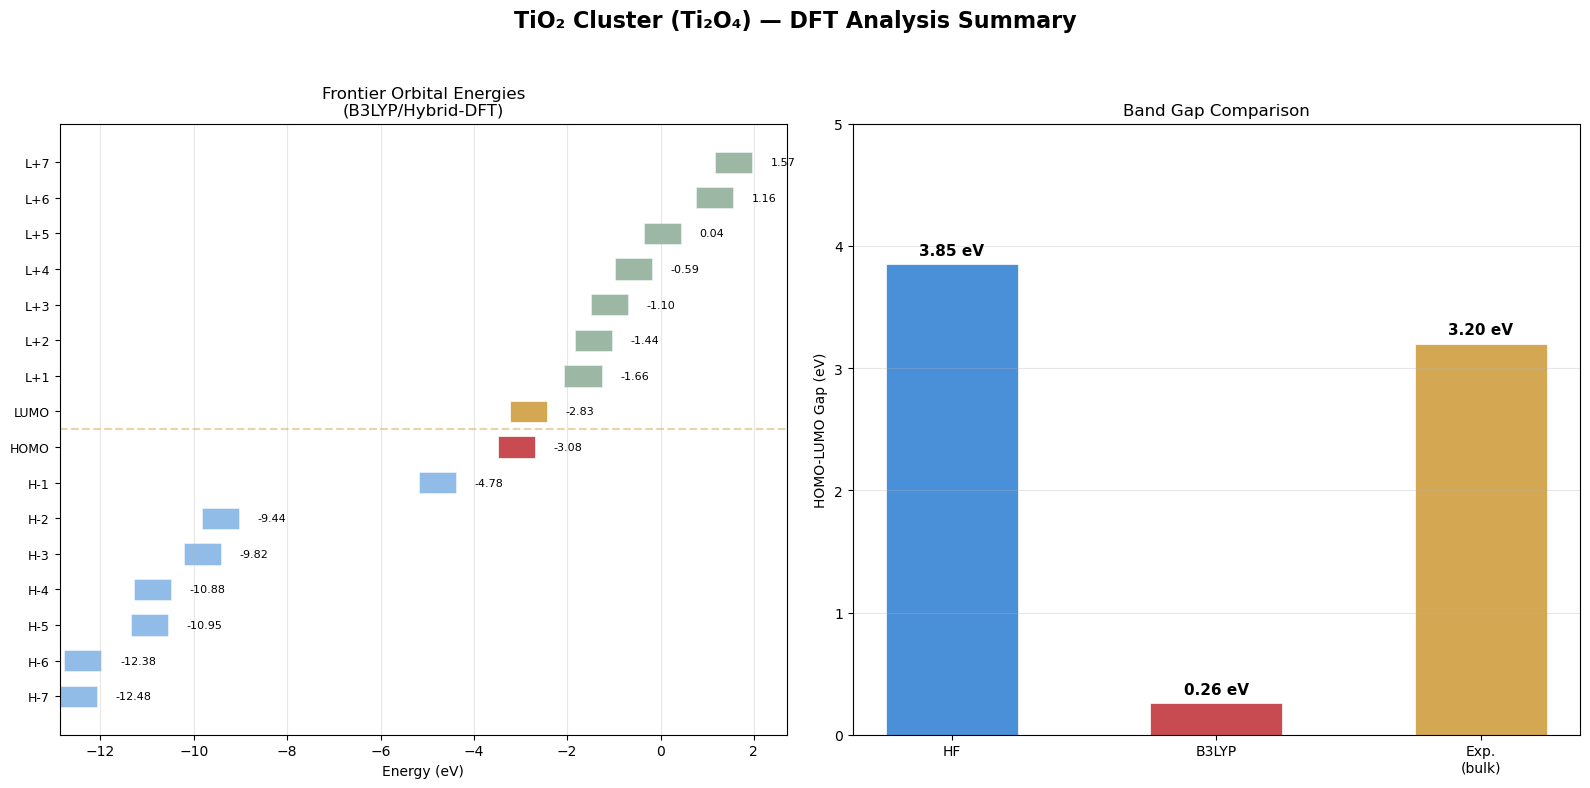

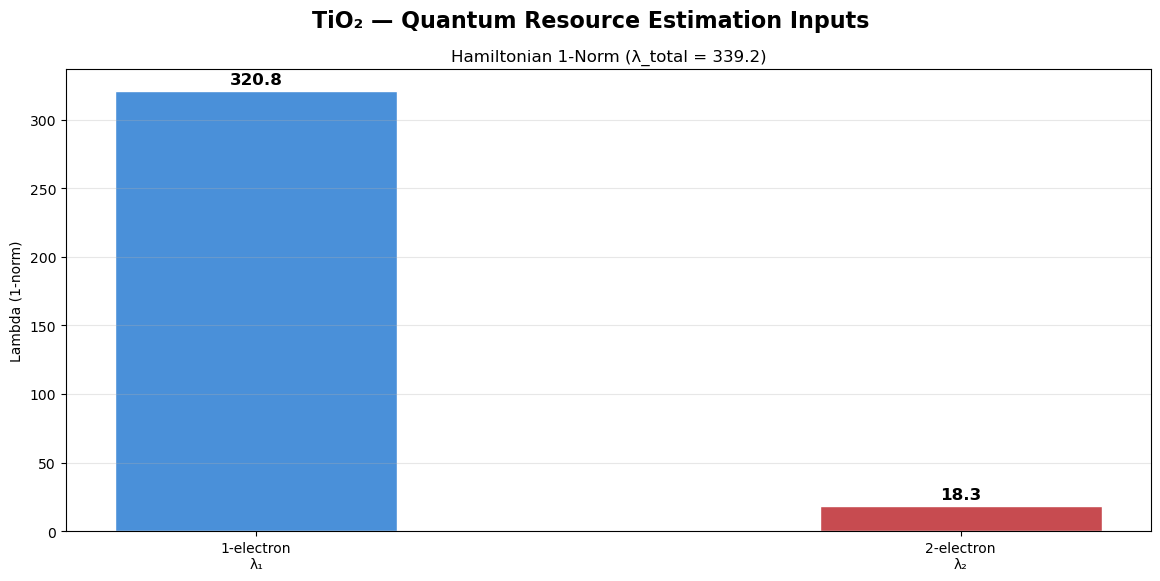

In [8]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

gap_hf = (mo_energy[lumo_idx] - mo_energy[homo_idx]) * 27.2114
gap_dft = (mo_e_dft[l_dft] - mo_e_dft[h_dft]) * 27.2114

# Frontier orbital data
orb_labels = []
orb_energies = []
for i in range(max(0, h_dft - 7), min(mol.nao_nr(), l_dft + 8)):
    e = mo_e_dft[i] * 27.2114
    if i == h_dft: lab = "HOMO"
    elif i == l_dft: lab = "LUMO"
    elif i < h_dft: lab = f"H-{h_dft - i}"
    else: lab = f"L+{i - l_dft}"
    orb_labels.append(lab)
    orb_energies.append(e)


# === Style ===
ACCENT1 = '#c74b50'
ACCENT2 = '#4a90d9'
ACCENT3 = '#d4a853'
ACCENT4 = '#5a8a6a'
GRID = '#333355'


fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('TiO₂ Cluster (Ti₂O₄) — DFT Analysis Summary',
             fontsize=16, fontweight='bold', y=0.98)

# Panel 1: Frontier orbital energy levels
ax1 = axes[0]
for i, (lab, e) in enumerate(zip(orb_labels, orb_energies)):
    if lab == "HOMO": color, alpha = ACCENT1, 1.0
    elif lab == "LUMO": color, alpha = ACCENT3, 1.0
    elif "H" in lab: color, alpha = ACCENT2, 0.6
    else: color, alpha = ACCENT4, 0.6
    ax1.barh(i, 0.8, left=e - 0.4, height=0.6, color=color,
             alpha=alpha, edgecolor='white', linewidth=0.5)
    ax1.text(e + 0.8, i, f'{e:.2f}', va='center', fontsize=8)

ax1.set_yticks(range(len(orb_labels)))
ax1.set_yticklabels(orb_labels, fontsize=9)
ax1.set_xlabel('Energy (eV)')
ax1.set_title('Frontier Orbital Energies\n(B3LYP/Hybrid-DFT)', fontsize=12)
ax1.axhline(y=orb_labels.index("LUMO") - 0.5, color=ACCENT3,
            linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='x')

# Panel 2: HOMO-LUMO gap comparison
ax2 = axes[1]
methods = ['HF', 'B3LYP', 'Exp.\n(bulk)']
gaps = [gap_hf, gap_dft, 3.2]
colors = [ACCENT2, ACCENT1, ACCENT3]
bars = ax2.bar(methods, gaps, color=colors, edgecolor='white',
               linewidth=0.5, width=0.5)
for bar, val in zip(bars, gaps):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08,
             f'{val:.2f} eV', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('HOMO-LUMO Gap (eV)')
ax2.set_title('Band Gap Comparison', fontsize=12)
ax2.set_ylim(0, 5)
ax2.grid(True, alpha=0.3, axis='y')


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('tio2_dft_analysis.png', dpi=200, bbox_inches='tight',
             edgecolor='none')
plt.show()

# ========== FIGURE 2: Resource Estimation Inputs ==========
fig2, axes2 = plt.subplots(1, 1, figsize=(14, 6))
fig2.suptitle('TiO₂ — Quantum Resource Estimation Inputs',
              fontsize=16, fontweight='bold', y=0.98)

# Panel 1: Lambda breakdown
ax4 = axes2
labels_l = ['1-electron\nλ₁', '2-electron\nλ₂']
values_l = [lambda_1e, lambda_2e]
bars4 = ax4.bar(labels_l, values_l, color=[ACCENT2, ACCENT1],
                edgecolor='white', width=0.4)
for b, v in zip(bars4, values_l):
    ax4.text(b.get_x() + b.get_width() / 2, b.get_height() + 5,
             f'{v:.1f}', ha='center', fontsize=12, fontweight='bold')
ax4.set_ylabel('Lambda (1-norm)')
ax4.set_title(f'Hamiltonian 1-Norm (λ_total = {lambda_total:.1f})',
              fontsize=12)
ax4.grid(True, alpha=0.3, axis='y')

plt.show()